In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score



# **Prepare Data**
1. Load dataset
2. Copy feature names
3. Convert string labels to binary
4. Train test split
5. Check for missing data
6. Standardize features
7. Drop highly correlated features

In [2]:
# load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
df = pd.read_csv(url)

In [3]:
df.head(4)

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# rename columns based on wdbc.names
columns = [
	'id_number',
	'diagnosis', # M = malignant, B = benign
]

stat_map = {
	0:'mean', 
	1:'standard_error', 
	2:'worst'
}

features = {
	0:'radius', 
	1:'texture', 
	2:'perimeter', 
	3:'area', 
	4:'smoothness', 
	5:'compactness',
	6:'concavity',
	7:'concave_points',
	8:'symmetry',
	9:'fractal_dimension'
}

other_columns = [stat_map[i] + '_' + features[j] for i in range(3) for j in range(10)]

columns.extend(other_columns)

df.columns = columns

From wdbc.names, explanation of columns

Ten real-valued features are computed for each cell nucleus:

	a) radius (mean of distances from center to points on the perimeter)
	b) texture (standard deviation of gray-scale values)
	c) perimeter
	d) area
	e) smoothness (local variation in radius lengths)
	f) compactness (perimeter^2 / area - 1.0)
	g) concavity (severity of concave portions of the contour)
	h) concave points (number of concave portions of the contour)
	i) symmetry 
	j) fractal dimension ("coastline approximation" - 1)

The mean, standard error, and "worst" or largest (mean of the three
largest values) of these features were computed for each image,
resulting in 30 features.  For instance, field 3 is Mean Radius, field
13 is Radius SE, field 23 is Worst Radius.

In [5]:
df.head()

,id_number,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [6]:
# convert 'diagnosis' column to binary
diagnosis = df['diagnosis']
diagnosis = diagnosis.map({"M": 1, "B": 0})

df['diagnosis'] = diagnosis

In [7]:
df

,id_number,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
1,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
2,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
3,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
4,843786,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.470,23.75,103.40,741.6,0.17910,0.52490,0.5355,0.1741,0.3985,0.12440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
564,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
565,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
566,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [8]:
# train test split
X = df.drop(['id_number', 'diagnosis'], axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2
)

In [9]:
X_train

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
11,19.170,24.80,132.40,1123.0,0.09740,0.24580,0.206500,0.111800,0.2397,0.07800,...,20.960,29.94,151.70,1332.0,0.10370,0.39030,0.36390,0.17670,0.3176,0.10230
244,10.480,19.86,66.72,337.7,0.10700,0.05971,0.048310,0.030700,0.1737,0.06440,...,11.480,29.46,73.68,402.8,0.15150,0.10260,0.11810,0.06736,0.2883,0.07748
94,20.260,23.03,132.40,1264.0,0.09078,0.13130,0.146500,0.086830,0.2095,0.05649,...,24.220,31.59,156.10,1750.0,0.11900,0.35390,0.40980,0.15730,0.3689,0.08368
286,12.890,13.12,81.89,515.9,0.06955,0.03729,0.022600,0.011710,0.1337,0.05581,...,13.620,15.54,87.40,577.0,0.09616,0.11470,0.11860,0.05366,0.2309,0.06915
344,10.260,14.71,66.20,321.6,0.09882,0.09159,0.035810,0.020370,0.1633,0.07005,...,10.880,19.48,70.89,357.1,0.13600,0.16360,0.07162,0.04074,0.2434,0.08488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,11.930,10.91,76.14,442.7,0.08872,0.05242,0.026060,0.017960,0.1601,0.05541,...,13.800,20.14,87.64,589.5,0.13740,0.15750,0.15140,0.06876,0.2460,0.07262
70,8.888,14.64,58.79,244.0,0.09783,0.15310,0.086060,0.028720,0.1902,0.08980,...,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
44,18.650,17.60,123.70,1076.0,0.10990,0.16860,0.197400,0.100900,0.1907,0.06049,...,22.820,21.32,150.60,1567.0,0.16790,0.50900,0.73450,0.23780,0.3799,0.09185
76,18.050,16.15,120.20,1006.0,0.10650,0.21460,0.168400,0.108000,0.2152,0.06673,...,22.390,18.91,150.10,1610.0,0.14780,0.56340,0.37860,0.21020,0.3751,0.11080


In [10]:
# check for missing values
X_train.isna().sum()

mean_radius                         0
mean_texture                        0
mean_perimeter                      0
mean_area                           0
mean_smoothness                     0
mean_compactness                    0
mean_concavity                      0
mean_concave_points                 0
mean_symmetry                       0
mean_fractal_dimension              0
standard_error_radius               0
standard_error_texture              0
standard_error_perimeter            0
standard_error_area                 0
standard_error_smoothness           0
standard_error_compactness          0
standard_error_concavity            0
standard_error_concave_points       0
standard_error_symmetry             0
standard_error_fractal_dimension    0
worst_radius                        0
worst_texture                       0
worst_perimeter                     0
worst_area                          0
worst_smoothness                    0
worst_compactness                   0
worst_concav

In [12]:
# standardize columns of training data
scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)

X_train.columns = other_columns
X_train

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
11,1.534401,1.290340,1.787093,1.449484,0.098155,2.890572,1.638582,1.792828,2.244998,2.195815,...,1.049671,0.708414,1.426706,0.876713,-1.239179,0.935504,0.500212,1.023752,0.538613,1.065928
244,-1.023253,0.150354,-1.028358,-0.895371,0.795808,-0.823637,-0.469684,-0.432721,-0.237010,0.244553,...,-0.972362,0.631187,-0.983511,-0.827563,0.869587,-0.926891,-0.696628,-0.679891,0.020578,-0.342101
94,1.855211,0.881883,1.787093,1.870501,-0.382934,0.605243,0.838936,1.107600,1.109291,-0.890336,...,1.745011,0.973880,1.562633,1.643380,-0.564198,0.699872,0.723707,0.721478,1.445618,0.009623
286,-0.313938,-1.405011,-0.378078,-0.363277,-1.925765,-1.271122,-0.812332,-0.953845,-1.741258,-0.987899,...,-0.515912,-1.608384,-0.559668,-0.508057,-1.571817,-0.848563,-0.694193,-0.893353,-0.994277,-0.814659
344,-1.088003,-1.038093,-1.050648,-0.943444,0.201350,-0.187337,-0.636277,-0.716197,-0.628114,1.055187,...,-1.100339,-0.974483,-1.069700,-0.911383,0.185782,-0.532014,-0.922947,-1.094661,-0.773272,0.077698
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,-0.596487,-1.915005,-0.624558,-0.581848,-0.532639,-0.969140,-0.766219,-0.782332,-0.748454,-1.045289,...,-0.477519,-0.868296,-0.552254,-0.485130,0.247545,-0.571502,-0.534485,-0.658078,-0.727303,-0.617807
70,-1.491812,-1.054246,-1.368287,-1.175153,0.129405,1.040353,0.033426,-0.487056,0.383492,3.888822,...,-1.344988,-1.587469,-1.327033,-1.044724,-0.489200,-0.014143,-0.573438,-0.983724,-1.091519,1.411979
44,1.381354,-0.371178,1.414157,1.309145,1.006558,1.349721,1.517302,1.493710,0.402295,-0.316435,...,1.446399,-0.678447,1.392725,1.307734,1.593096,1.703895,2.304724,1.975760,1.640102,0.473104
76,1.204761,-0.705789,1.264126,1.100130,0.759472,2.267845,1.130807,1.688548,1.323647,0.578850,...,1.354682,-1.066189,1.377279,1.386602,0.706356,2.056048,0.571789,1.545721,1.555236,1.548130


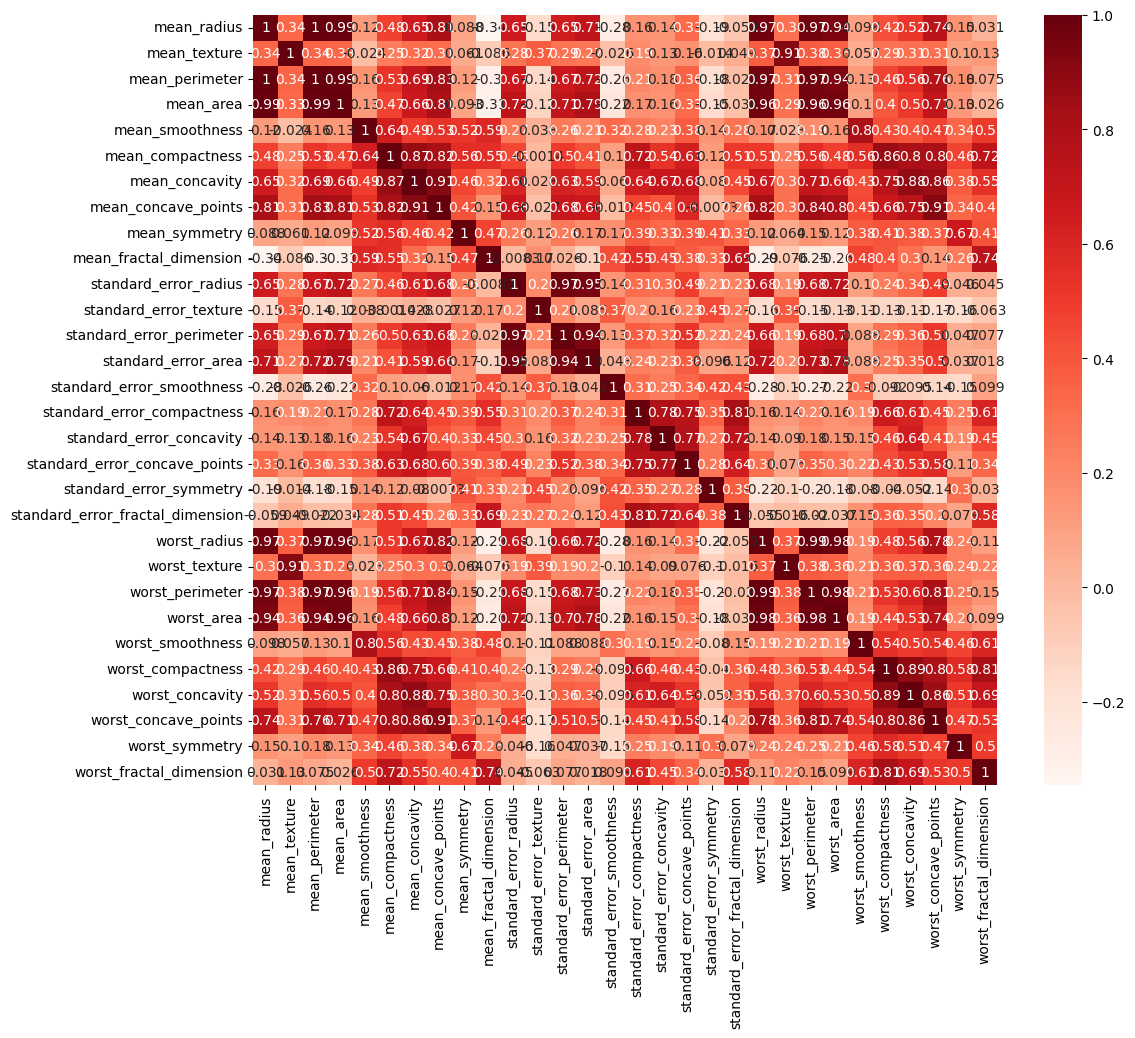

In [13]:
# plot correlation matrix
plt.figure(figsize=(12,10))
corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=True, cmap=plt.cm.Reds)
plt.show()

In [14]:
# drop highly correlated features
corr_matrix = corr_matrix.abs()

# drop from training set
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_train_light = X_train.drop(to_drop, axis=1)
print(f"Dropped {len(to_drop)} features: {to_drop}")

# drop from test set
X_test_standardized = scaler.transform(X_test)
X_test_light = X_test_standardized.drop(columns=to_drop)

Dropped 10 features: ['mean_perimeter', 'mean_area', 'mean_concave_points', 'standard_error_perimeter', 'standard_error_area', 'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area', 'worst_concave_points']


# **Compare Models**

In [ ]:
non_regularized_model = LogisticRegression()
l1_log_reg_model = LogisticRegression(penalty='l1', solver='liblinear', C=5)
l2_log_reg_model = LogisticRegression(penalty='l2', C=5)

In [154]:
def fit_predict_proba(X_train, y_train, X_test, model):
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1] # get the model's guesses as probabilities, then get only the probabilities of being malignant
    return model, probs

In [155]:
l1_log_reg_model, l1_probs = fit_predict_proba(X_train_light, y_train, X_test_light, l1_log_reg_model)
l2_log_reg_model, l2_probs = fit_predict_proba(X_train_light, y_train, X_test_light, l2_log_reg_model)

In [156]:
l1_probs

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [157]:
l2_probs

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [158]:
nonzero_l1_coefs = np.abs(l1_log_reg_model.coef_[0]) > 0
nonzero_l1_coefs.sum()

np.int64(17)

In [159]:
l2_log_reg_model.coef_.shape

(1, 20)

In [160]:
nonzero_l1_coefs

array([ True,  True,  True,  True,  True,  True, False,  True, False,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True])

In [161]:
np.array(X_train_light.columns)

array(['mean_radius', 'mean_texture', 'mean_smoothness',
       'mean_compactness', 'mean_concavity', 'mean_symmetry',
       'mean_fractal_dimension', 'standard_error_radius',
       'standard_error_texture', 'standard_error_smoothness',
       'standard_error_compactness', 'standard_error_concavity',
       'standard_error_concave_points', 'standard_error_symmetry',
       'standard_error_fractal_dimension', 'worst_smoothness',
       'worst_compactness', 'worst_concavity', 'worst_symmetry',
       'worst_fractal_dimension'], dtype=object)

In [162]:
l1_removed_features = np.array(X_train_light.columns)[~nonzero_l1_coefs]
print(l1_removed_features.shape)
l1_removed_features


(3,)


array(['mean_fractal_dimension', 'standard_error_texture',
       'worst_compactness'], dtype=object)

l1 eliminated 6 features. 'mean_smoothness', 'mean_compactness', 'mean_symmetry', 'standard_error_texture', 'standard_error_smoothness', 'worst_compactness'

In [163]:
def most_important_feature(model_coef):

    model_coef_weights = pd.Series(
        index = X_test_light.columns,
        data = np.abs(model_coef)
    )

    return model_coef_weights.idxmax()

In [164]:
most_important_feature(l1_log_reg_model.coef_[0])

'standard_error_radius'

In [165]:
most_important_feature(l2_log_reg_model.coef_[0])

'standard_error_radius'

mean_radius is the most important feature in determining whether a tumor is malignant for both l1 and l2 logistic regression. 

recall can be higher by adjusting threshold of when the model predicts a tumor as being malignant

use precision-recall curve to choose best threshold

In [166]:
target_recall = 0.95

def optimal_threshold_for_target_recall(probs):
    precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, color='blue', label='Logistic Regression')
    plt.xlabel('Recall (Sensitivity)')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.grid(True)
    plt.show()

    # optimal threshold is where recall is at least 95%
    idx = (recalls >= target_recall).argmin() - 1 # (recalls >= target_recall) returns a boolean array
    # and argmin finds the index of the first false. so subtract by one to find index of the last true
    opt_threshold = thresholds[idx] # get optimal threshold
    print(f"To get {target_recall*100}% recall, use a threshold of: {opt_threshold:.4f}")
    return opt_threshold

In [167]:
def predict_using_threshold(probs, probability_threshold):
    predictions = (probs >= probability_threshold).astype(int)
    return predictions

In [168]:
def confusion_matrix_and_recall(test_labels, model_predictions):
    cm = confusion_matrix(test_labels, model_predictions)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(cmap='Blues')
    plt.show()

    true_positives = cm[1,1]
    false_positives = cm[0,1]
    false_negatives = cm[1,0]
    true_negatives = cm[0,0]

    actual_positives = true_positives + false_negatives
    actual_negatives = false_positives + true_negatives

    recall = true_positives / actual_positives
    print('recall:', recall)


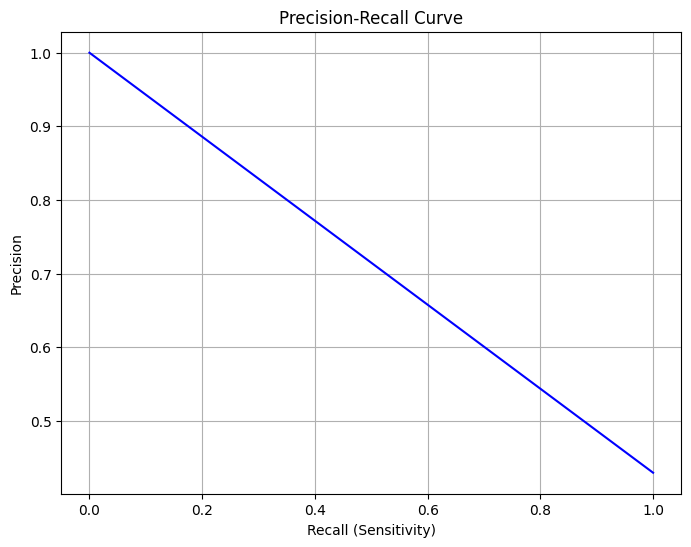

To get 95.0% recall, use a threshold of: 1.0000


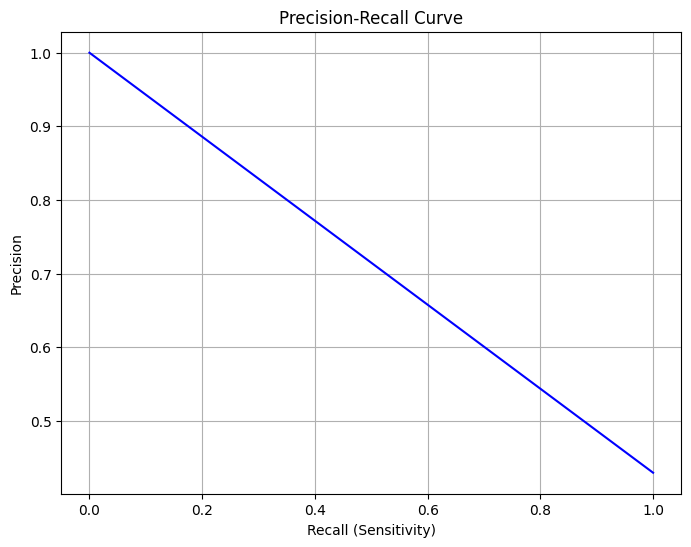

To get 95.0% recall, use a threshold of: 1.0000


In [169]:
l1_threshold = optimal_threshold_for_target_recall(l1_probs)
l2_threshold = optimal_threshold_for_target_recall(l2_probs)

In [170]:
l1_predictions = predict_using_threshold(l1_probs, l1_threshold)
l2_predictions = predict_using_threshold(l2_probs, l2_threshold)

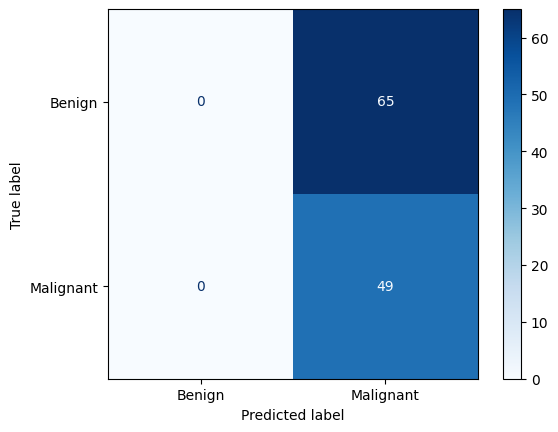

recall: 1.0


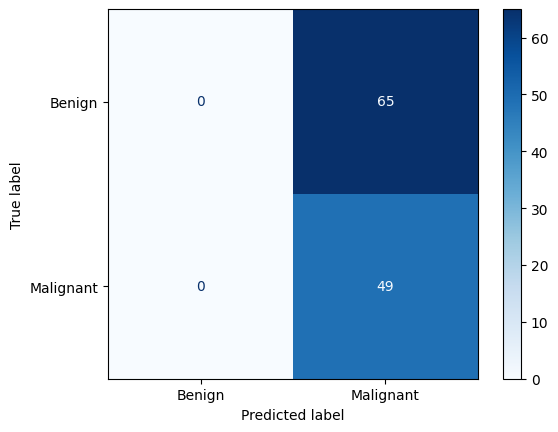

recall: 1.0


In [171]:
confusion_matrix_and_recall(y_test, l1_predictions)
confusion_matrix_and_recall(y_test, l2_predictions)

In [172]:
l1_ap_score = average_precision_score(y_test, l1_predictions)
l1_ap_score

0.4298245614035088

In [173]:
l2_ap_score = average_precision_score(y_test, l2_predictions)
l2_ap_score

0.4298245614035088